# Optimized+augmented PyTorch CNN

In this notebook, we train the winning CNN architecture from the Optuna run in notebook 04, using the optimized training strategy from notebook 05, on the CIFAR-10 dataset with image augmentation for improved generalization.

## Notebook set-up

### Imports

In [1]:
# Standard library imports
import pickle

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# Package imports
import image_classification_tools.pytorch.data as data_utils
import image_classification_tools.pytorch.evaluation as eval_utils
import image_classification_tools.pytorch.hyperparameter_optimization as optimization
import image_classification_tools.pytorch.plotting as plots
import image_classification_tools.pytorch.training as training

# Local imports
import configuration as config

Using device: cuda


### Hyperparameters

In [2]:
# Split sizes
val_size = 10000

# Training
epochs = 500 # Early stopping will end training when validation loss plateaus 
print_every = 25

## 1. Load optimization results

In [3]:
# Load architecture optimization study from notebook 04
architecture_study = optuna.load_study(
    study_name='architecture_optimization',
    storage=config.OPTUNA_STORAGE_URL
)

# Get best architecture parameters
arch_params = architecture_study.best_trial.params

print('Best architecture hyperparameters from notebook 04:\n')
for key, value in arch_params.items():
    print(f'  {key}: {value}')

print(f'\nBest validation accuracy: {architecture_study.best_trial.value:.2f}%')

# Load training optimization study from notebook 05
training_study = optuna.load_study(
    study_name='training_optimization',
    storage=config.OPTUNA_STORAGE_URL
)

# Get best training parameters
training_params = training_study.best_trial.params

print('\nBest training hyperparameters from notebook 05:\n')
for key, value in training_params.items():
    print(f'  {key}: {value}')

print(f'\nBest validation accuracy: {training_study.best_trial.value:.2f}%')

# Get batch size from architecture optimization
batch_size = arch_params['batch_size']


Best architecture hyperparameters from notebook 04:

  batch_size: 64
  n_conv_blocks: 7
  initial_filters: 64
  n_fc_layers: 2
  conv_dropout_rate: 0.265682054912767
  fc_dropout_rate: 0.5786665563752931
  learning_rate: 0.0004134004326389953

Best validation accuracy: 87.30%

Best training hyperparameters from notebook 05:

  optimizer: SGD
  learning_rate: 0.0007939803854054807
  weight_decay: 1.2753580345166475e-05
  momentum: 0.9593372775850291
  nesterov: False

Best validation accuracy: 89.21%


## 2. Load and preprocess CIFAR-10 data

Load the images into PyTorch tensors and split them into training, validation and testing datasets. Augmentation is applied on-the-fly during training for better generalization.

### 2.1. Define preprocessing transforms

In [4]:
# Training transform with on-the-fly augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.1),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

# Evaluation transform (no augmentation)
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

### 2.2. Load the training and testing datasets from disk

In [5]:
# Training data with augmentation
train_dataset = data_utils.load_dataset(
    data_source=datasets.CIFAR10,
    transform=train_transform,
    root=config.DATA_DIR
)

# Test data without augmentation
test_dataset = data_utils.load_dataset(
    data_source=datasets.CIFAR10,
    transform=eval_transform,
    root=config.DATA_DIR,
    train=False
)

### 2.3. Training, validation and testing split

In [6]:
train_dataset, val_dataset, test_dataset = data_utils.prepare_splits(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    val_size=val_size
)

### 2.4. Create dataloaders

Create DataLoaders with on-the-fly augmentation applied during training.

In [7]:
# Create DataLoaders (augmentation applied on-the-fly during training)
train_loader, val_loader, test_loader = data_utils.create_dataloaders(
    train_dataset, val_dataset, test_dataset,
    batch_size=batch_size,
    preload_to_memory=False,  # Keep False for on-the-fly augmentation
    device=config.DEVICE
)

print(f'Batch size: {batch_size}')
print(f'Training set: {len(train_dataset)} images')
print(f'Validation set: {len(val_dataset)} images')
print(f'Test set: {len(test_dataset)} images')

Batch size: 64
Training set: 40000 images
Validation set: 10000 images
Test set: 10000 images


## 3. Build optimized CNN using best hyperparameters

Create a CNN using the best hyperparameters found during Optuna optimization, then train it with on-the-fly data augmentation.

### 3.1. Create model with best hyperparameters

In [8]:
# Create model with best hyperparameters from architecture optimization (notebook 04)
model = optimization.create_cnn(
    n_conv_blocks=arch_params['n_conv_blocks'],
    initial_filters=arch_params['initial_filters'],
    n_fc_layers=arch_params['n_fc_layers'],
    conv_dropout_rate=arch_params['conv_dropout_rate'],
    fc_dropout_rate=arch_params['fc_dropout_rate'],
    num_classes=len(config.CLASS_NAMES),
    in_channels=3
).to(config.DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nTotal parameters: {trainable_params:,}')


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Dropout(p=0.265682054912767, inplace=False)
  (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU()
  (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): ReLU()
  (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (14): Dropout(p=0.265682054912767, inplace=False)
  (15): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (16): BatchNorm2d(128, eps=

### 3.2. Define loss function and optimizer

Use the optimized training hyperparameters from notebook 05.

In [9]:
def create_optimizer(optimizer_name, model_params, lr, weight_decay, **kwargs):
    '''
    Create an optimizer instance based on the specified configuration.
    
    Args:
        optimizer_name: Name of optimizer ('Adam', 'SGD', or 'RMSprop')
        model_params: Model parameters (from model.parameters())
        lr: Learning rate
        weight_decay: Weight decay (L2 regularization)
        **kwargs: Optimizer-specific parameters (beta1, beta2, momentum, nesterov, alpha)
    
    Returns:
        optimizer: Configured PyTorch optimizer
    '''

    if optimizer_name == 'Adam':
        beta1 = kwargs.get('beta1', 0.9)
        beta2 = kwargs.get('beta2', 0.999)
        optimizer = optim.Adam(
            model_params,
            lr=lr,
            betas=(beta1, beta2),
            weight_decay=weight_decay
        )
    
    elif optimizer_name == 'SGD':
        momentum = kwargs.get('momentum', 0.0)
        nesterov = kwargs.get('nesterov', False) if momentum > 0 else False
        optimizer = optim.SGD(
            model_params,
            lr=lr,
            momentum=momentum,
            nesterov=nesterov,
            weight_decay=weight_decay
        )
    
    elif optimizer_name == 'RMSprop':
        alpha = kwargs.get('alpha', 0.99)
        momentum = kwargs.get('momentum', 0.0)
        optimizer = optim.RMSprop(
            model_params,
            lr=lr,
            alpha=alpha,
            momentum=momentum,
            weight_decay=weight_decay
        )
    
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")
    
    return optimizer


# Extract optimizer configuration from training optimization (notebook 05)
optimizer_name = training_params['optimizer']
lr = training_params['learning_rate']
weight_decay = training_params['weight_decay']

# Extract optimizer-specific parameters
optimizer_kwargs = {}

if optimizer_name == 'Adam':
    optimizer_kwargs['beta1'] = training_params['beta1']
    optimizer_kwargs['beta2'] = training_params['beta2']

elif optimizer_name == 'SGD':
    optimizer_kwargs['momentum'] = training_params['momentum']
    optimizer_kwargs['nesterov'] = training_params.get('nesterov', False)

elif optimizer_name == 'RMSprop':
    optimizer_kwargs['alpha'] = training_params['alpha']
    optimizer_kwargs['momentum'] = training_params['momentum']

# Create optimizer using helper function
optimizer = create_optimizer(
    optimizer_name=optimizer_name,
    model_params=model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
    **optimizer_kwargs
)

# Print configuration
print(f'Using {optimizer_name} optimizer:')
print(f'  lr={lr:.6f}')
print(f'  weight_decay={weight_decay:.6f}')
for key, value in optimizer_kwargs.items():
    print(f'  {key}={value}')

# Set cross-entropy loss
criterion = nn.CrossEntropyLoss()


Using SGD optimizer:
  lr=0.000794
  weight_decay=0.000013
  momentum=0.9593372775850291
  nesterov=False


### 3.3. Train model

In [10]:
%%time

history = training.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=config.DEVICE,
    lazy_loading=True,  # Move data to device during training (not preloaded)
    epochs=epochs,
    print_every=print_every,
    enable_early_stopping=True,
    early_stopping_patience=10
)

print()

Epoch   1/500 - loss: 2.0776 - acc: 19.16% - val_loss: 2.4027 - val_acc: 15.43%
Epoch  25/500 - loss: 0.7161 - acc: 77.11% - val_loss: 0.6547 - val_acc: 78.72%
Epoch  50/500 - loss: 0.5025 - acc: 83.87% - val_loss: 0.4701 - val_acc: 84.59%
Epoch  75/500 - loss: 0.3994 - acc: 87.34% - val_loss: 0.4013 - val_acc: 86.79%

Early stopping at epoch 96
Best val_loss: 0.3740 at epoch 86
Restored best model weights

CPU times: user 6h 29min 31s, sys: 49.9 s, total: 6h 30min 21s
Wall time: 3h 9min 50s


### 3.4. Learning curves

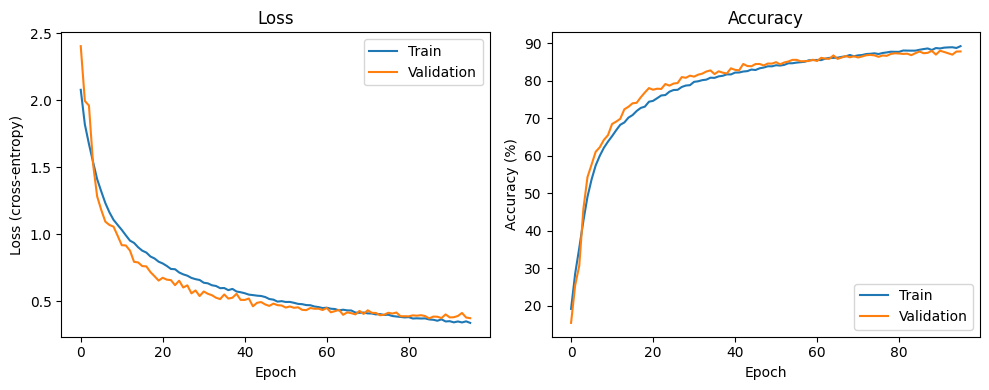

In [11]:
fig, axes = plots.plot_learning_curves(history)
plt.show()

## 4. Evaluate model on test set

### 4.1. Calculate test accuracy

In [12]:
test_accuracy, predictions, true_labels = eval_utils.evaluate_model(model, test_loader)
print(f'Test accuracy: {test_accuracy:.2f}%')

Test accuracy: 90.88%


### 4.2. Per-class accuracy

In [13]:
# Calculate per-class accuracy
class_correct = {name: 0 for name in config.CLASS_NAMES}
class_total = {name: 0 for name in config.CLASS_NAMES}

for pred, true in zip(predictions, true_labels):

    class_name = config.CLASS_NAMES[true]
    class_total[class_name] += 1

    if pred == true:
        class_correct[class_name] += 1

print('Per-class accuracy:')
print('-' * 30)

for name in config.CLASS_NAMES:
    acc = 100 * class_correct[name] / class_total[name]
    print(f'{name:12s}: {acc:.2f}%')

Per-class accuracy:
------------------------------
airplane    : 91.50%
automobile  : 96.80%
bird        : 86.90%
cat         : 74.90%
deer        : 90.00%
dog         : 88.70%
frog        : 94.00%
horse       : 94.60%
ship        : 95.30%
truck       : 96.10%


### 4.3. Confusion matrix

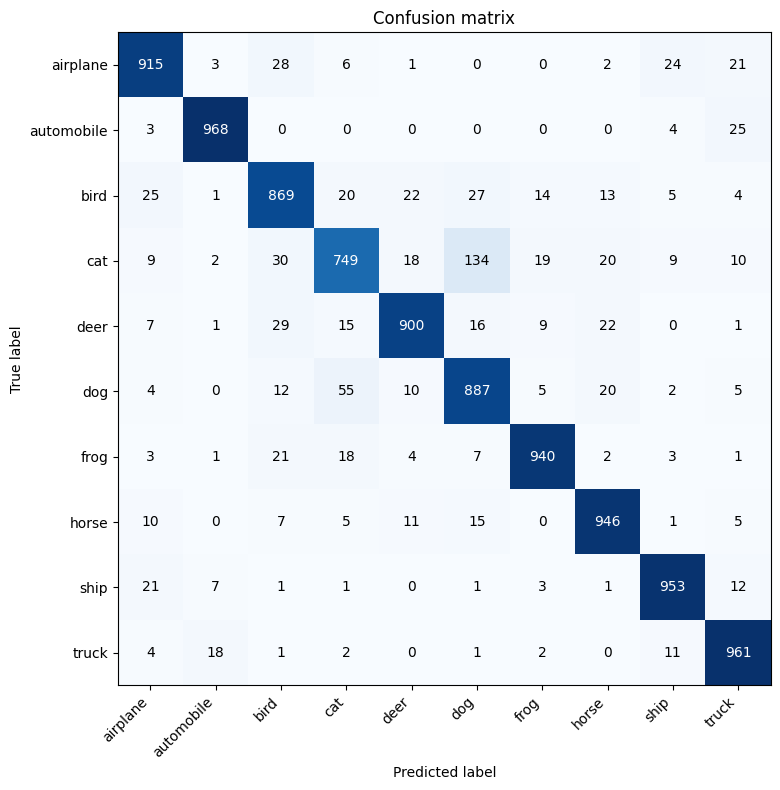

In [14]:
fig, ax = plots.plot_confusion_matrix(true_labels, predictions, config.CLASS_NAMES)
plt.show()

### 4.4. Predicted class probability distributions

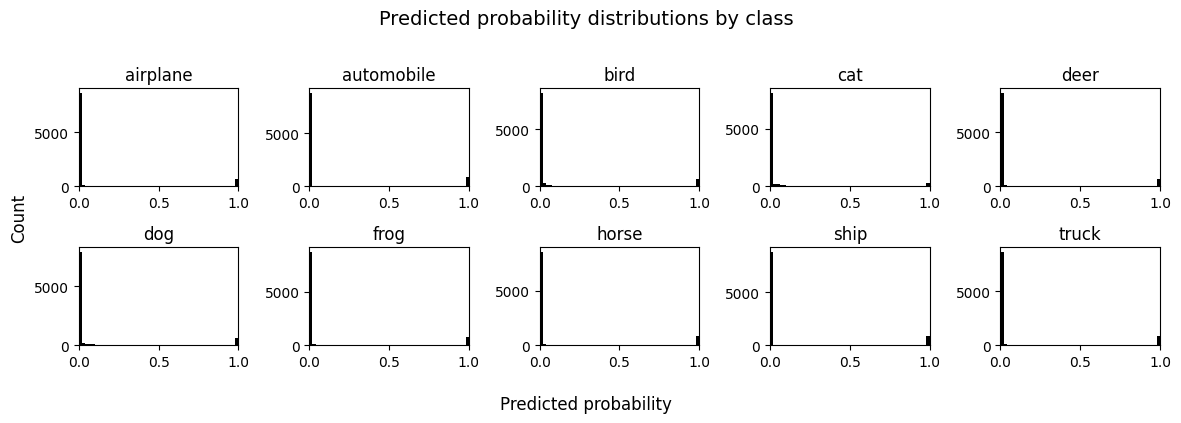

In [15]:
# Get predicted probabilities for all test samples
model.eval()
all_probs = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(config.DEVICE, non_blocking=True)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)

# Plot probability distributions
fig, axes = plots.plot_class_probability_distributions(all_probs, config.CLASS_NAMES)
plt.show()

### 4.5. Evaluation curves

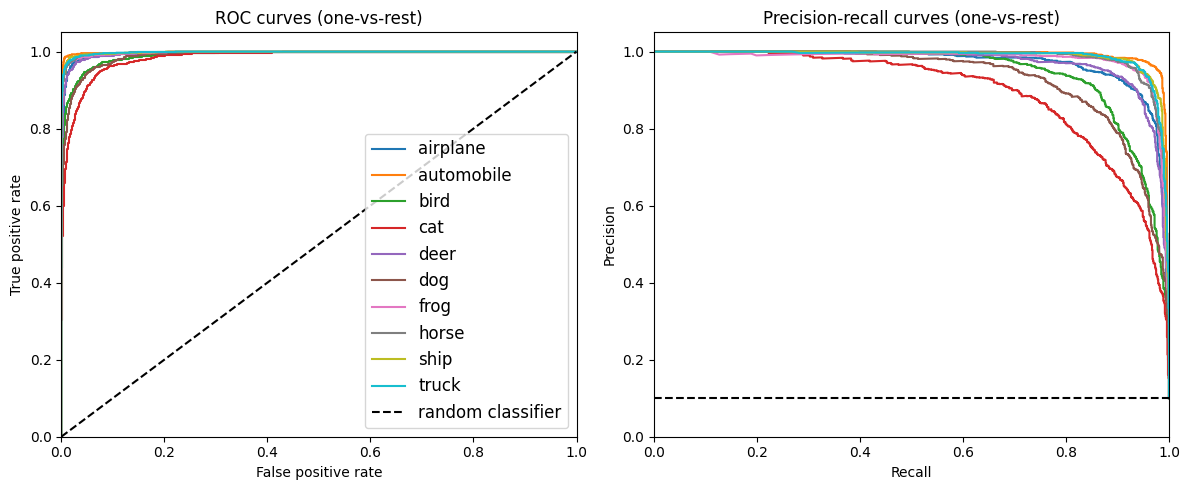

In [16]:
fig, (ax1, ax2) = plots.plot_evaluation_curves(true_labels, all_probs, config.CLASS_NAMES)
plt.show()

## 5. Save model

In [17]:
# Save trained model
model_path = config.MODELS_DIR / 'augmented_cnn.pth'
torch.save(model, model_path)

print(f'Model saved to: {model_path}')
print(f'Test accuracy: {test_accuracy:.2f}%')

Model saved to: ../models/pytorch/augmented_cnn.pth
Test accuracy: 90.88%


## 6. Save test results for comparison

In [18]:
# Save results path
results_path = config.RESULTS_DIR / 'augmented_cnn_results.pkl'

# Count model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Create results dictionary
results_dict = {
    'true_labels': true_labels,
    'predictions': predictions,
    'all_probs': all_probs,
    'test_accuracy': test_accuracy,
    'total_params': total_params,
    'trainable_params': trainable_params
}

# Save results
with open(results_path, 'wb') as f:
    pickle.dump(results_dict, f)

print(f'Test results saved to: {results_path}')
print(f'  - Test accuracy: {test_accuracy:.2f}%')
print(f'  - Total parameters: {total_params:,}')
print(f'  - Trainable parameters: {trainable_params:,}')

Test results saved to: ../data/pytorch/performance_results/augmented_cnn_results.pkl
  - Test accuracy: 90.88%
  - Total parameters: 6,405,706
  - Trainable parameters: 6,405,706
